In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from sklearn.manifold import TSNE
from scipy.stats import ks_2samp

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
from sklearn.preprocessing import LabelEncoder

In [2]:
train = pd.read_csv('.dataset/train_original.csv')
test = pd.read_csv('./dataset/test_original.csv')

In [3]:
X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# SHAP

In [4]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import pandas as pd
import numpy as np
import shap
import sklearn
from sklearn.metrics import accuracy_score

print("="*70)
print("FEATURE SELECTION TỪ 3 MODELS: RF, XGB, ExtraTrees")
print("="*70)

models_info = {}

# ===== RANDOM FOREST =====
print("\n" + "="*70)
print("TRAINING RANDOM FOREST")
print("="*70)

rf_params = {
    "n_estimators": 100,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy"
}

rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"RandomForestClassifier Accuracy: {rf_acc:.4f}")
models_info['RF'] = {'model': rf_model, 'accuracy': rf_acc}

# ===== XGBOOST =====
print("\n" + "="*70)
print("TRAINING XGBOOST")
print("="*70)

num_classes = len(np.unique(y_train))
xgb_params = {
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor',
    'max_depth': 8,
    'n_estimators': 1000,
    'learning_rate': 0.1,
    'eval_metric': 'mlogloss',
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'booster': 'gbtree',
    'random_state': 42,
    'verbosity': 0,
    'n_jobs': -1
}

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBClassifier Accuracy: {xgb_acc:.4f}")
models_info['XGB'] = {'model': xgb_model, 'accuracy': xgb_acc}

# ===== EXTRATREES =====
print("\n" + "="*70)
print("TRAINING EXTRATREES")
print("="*70)

et_params = {
    "n_estimators": 100,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": False,
    "criterion": "entropy"
}

et_model = ExtraTreesClassifier(**et_params)
et_model.fit(X_train, y_train)
et_preds = et_model.predict(X_test)
et_acc = accuracy_score(y_test, et_preds)
print(f"ExtraTreesClassifier Accuracy: {et_acc:.4f}")
models_info['ET'] = {'model': et_model, 'accuracy': et_acc}

# ===== SHAP CALCULATION =====
print("\n" + "="*70)
print("TÍNH SHAP VALUES CHO 3 MODELS")
print("="*70)

feature_importances = {}

# RF
print("\nComputing SHAP for Random Forest...")
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_train)
mean_abs_shap_rf = np.mean(np.abs(shap_values_rf), axis=(0, 1))
feature_importances['RF'] = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_RF': mean_abs_shap_rf
}).sort_values('SHAP_RF', ascending=False)

# XGB
print("\nComputing SHAP for XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)
if isinstance(shap_values_xgb, list):
    mean_abs_shap_xgb = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_xgb], axis=0)
else:
    mean_abs_shap_xgb = np.mean(np.abs(shap_values_xgb), axis=(0, 1))
feature_importances['XGB'] = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_XGB': mean_abs_shap_xgb
}).sort_values('SHAP_XGB', ascending=False)

# ET
print("\nComputing SHAP for ExtraTrees...")
explainer_et = shap.TreeExplainer(et_model)
shap_values_et = explainer_et.shap_values(X_train)
mean_abs_shap_et = np.mean(np.abs(shap_values_et), axis=(0, 1))
feature_importances['ET'] = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_ET': mean_abs_shap_et
}).sort_values('SHAP_ET', ascending=False)

# ===== HỢP NHẤT FEATURE IMPORTANCE =====
print("\n" + "="*70)
print("KẾT HỢP FEATURE IMPORTANCE")
print("="*70)

feature_importance_combined = feature_importances['RF'].copy()
for model_name in ['XGB', 'ET']:
    feature_importance_combined = feature_importance_combined.merge(
        feature_importances[model_name], on='Feature', how='outer'
    )

feature_importance_combined = feature_importance_combined.fillna(0)

# Chuẩn hóa
for col in ['SHAP_RF', 'SHAP_XGB', 'SHAP_ET']:
    feature_importance_combined[f'{col}_Normalized'] = (
        feature_importance_combined[col] / feature_importance_combined[col].max()
    )

# Combined score
feature_importance_combined['Combined_Score'] = (
    feature_importance_combined['SHAP_RF_Normalized'] +
    feature_importance_combined['SHAP_XGB_Normalized'] +
    feature_importance_combined['SHAP_ET_Normalized']
) / 3

feature_importance_combined = feature_importance_combined.sort_values('Combined_Score', ascending=False)
print(feature_importance_combined.head(20)[
    ['Feature', 'SHAP_RF', 'SHAP_XGB', 'SHAP_ET', 'Combined_Score']
].to_string(index=False))

FEATURE SELECTION TỪ 3 MODELS: RF, XGB, ExtraTrees

TRAINING RANDOM FOREST
RandomForestClassifier Accuracy: 0.8486

TRAINING XGBOOST
XGBClassifier Accuracy: 0.8368

TRAINING EXTRATREES
ExtraTreesClassifier Accuracy: 0.8457

TÍNH SHAP VALUES CHO 3 MODELS

Computing SHAP for Random Forest...

Computing SHAP for XGBoost...

Computing SHAP for ExtraTrees...

KẾT HỢP FEATURE IMPORTANCE
                                         Feature  SHAP_RF  SHAP_XGB  SHAP_ET  Combined_Score
                                    flow IAT min 0.024230  0.982526 0.011089        0.864408
type_id_process_information_in_control_direction 0.011127  0.693785 0.018692        0.721787
 type_id_system_information_in_control_direction 0.012927  0.599707 0.012867        0.610751
                                      bw IAT min 0.012804  0.376432 0.010343        0.488304
                     flow packet APDU length max 0.010525  0.149085 0.011800        0.405807
                       bw packet APDU length max 0.009576 

In [5]:
# ===== UNION TOP 50 =====
print("\n" + "="*70)
print("CHỌN UNION CỦA TOP 50 FEATURES")
print("="*70)

top_50_sets = {}
for model_name, df in feature_importances.items():
    top_50_sets[model_name] = set(df.head(50)['Feature'].tolist())

final_features = set()
for features in top_50_sets.values():
    final_features |= features

feature_counts = {f: sum(f in s for s in top_50_sets.values()) for f in final_features}

for i in range(3, 0, -1):
    count = sum(1 for c in feature_counts.values() if c == i)
    if count > 0:
        print(f"In top 50 of {i}/3 models: {count} features")

final_features_sorted = feature_importance_combined[
    feature_importance_combined['Feature'].isin(final_features)
].sort_values('Combined_Score', ascending=False)['Feature'].tolist()

# ===== TẠO DATASETS =====
print("\n" + "="*70)
print("TẠO DATASETS VỚI FEATURES ĐÃ CHỌN")
print("="*70)

X_train_selected = X_train[final_features_sorted].copy()
X_test_selected = X_test[final_features_sorted].copy()

print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")


CHỌN UNION CỦA TOP 50 FEATURES
In top 50 of 3/3 models: 36 features
In top 50 of 2/3 models: 13 features
In top 50 of 1/3 models: 16 features

TẠO DATASETS VỚI FEATURES ĐÃ CHỌN
X_train_selected shape: (4800, 65)
X_test_selected shape: (2028, 65)


In [6]:
print("\n" + "="*70)
print("PHÂN TÍCH FINAL FEATURES")
print("="*70)

final_feature_details = feature_importance_combined[
    feature_importance_combined['Feature'].isin(final_features_sorted)
].sort_values('Combined_Score', ascending=False)

# Thêm cột số lượng models chứa feature trong top 40
final_feature_details['In_N_Models'] = final_feature_details['Feature'].map(feature_counts)

print(f"\n Chi tiết {len(final_features_sorted)} features đã chọn:")
print(final_feature_details[[
    'Feature', 'In_N_Models', 'SHAP_RF', 'SHAP_XGB', 'SHAP_ET', 'Combined_Score'
]].head(50).to_string(index=False))


PHÂN TÍCH FINAL FEATURES

 Chi tiết 65 features đã chọn:
                                         Feature  In_N_Models  SHAP_RF  SHAP_XGB  SHAP_ET  Combined_Score
                                    flow IAT min            3 0.024230  0.982526 0.011089        0.864408
type_id_process_information_in_control_direction            3 0.011127  0.693785 0.018692        0.721787
 type_id_system_information_in_control_direction            3 0.012927  0.599707 0.012867        0.610751
                                      bw IAT min            3 0.012804  0.376432 0.010343        0.488304
                     flow packet APDU length max            3 0.010525  0.149085 0.011800        0.405807
                       bw packet APDU length max            3 0.009576  0.376436 0.007906        0.400439
                                           cot=1            3 0.006967  0.177819 0.010121        0.336673
                       bw packet APDU length std            3 0.007366  0.354362 0.005827     

## PLOT 1: Top 50 Features Comparison

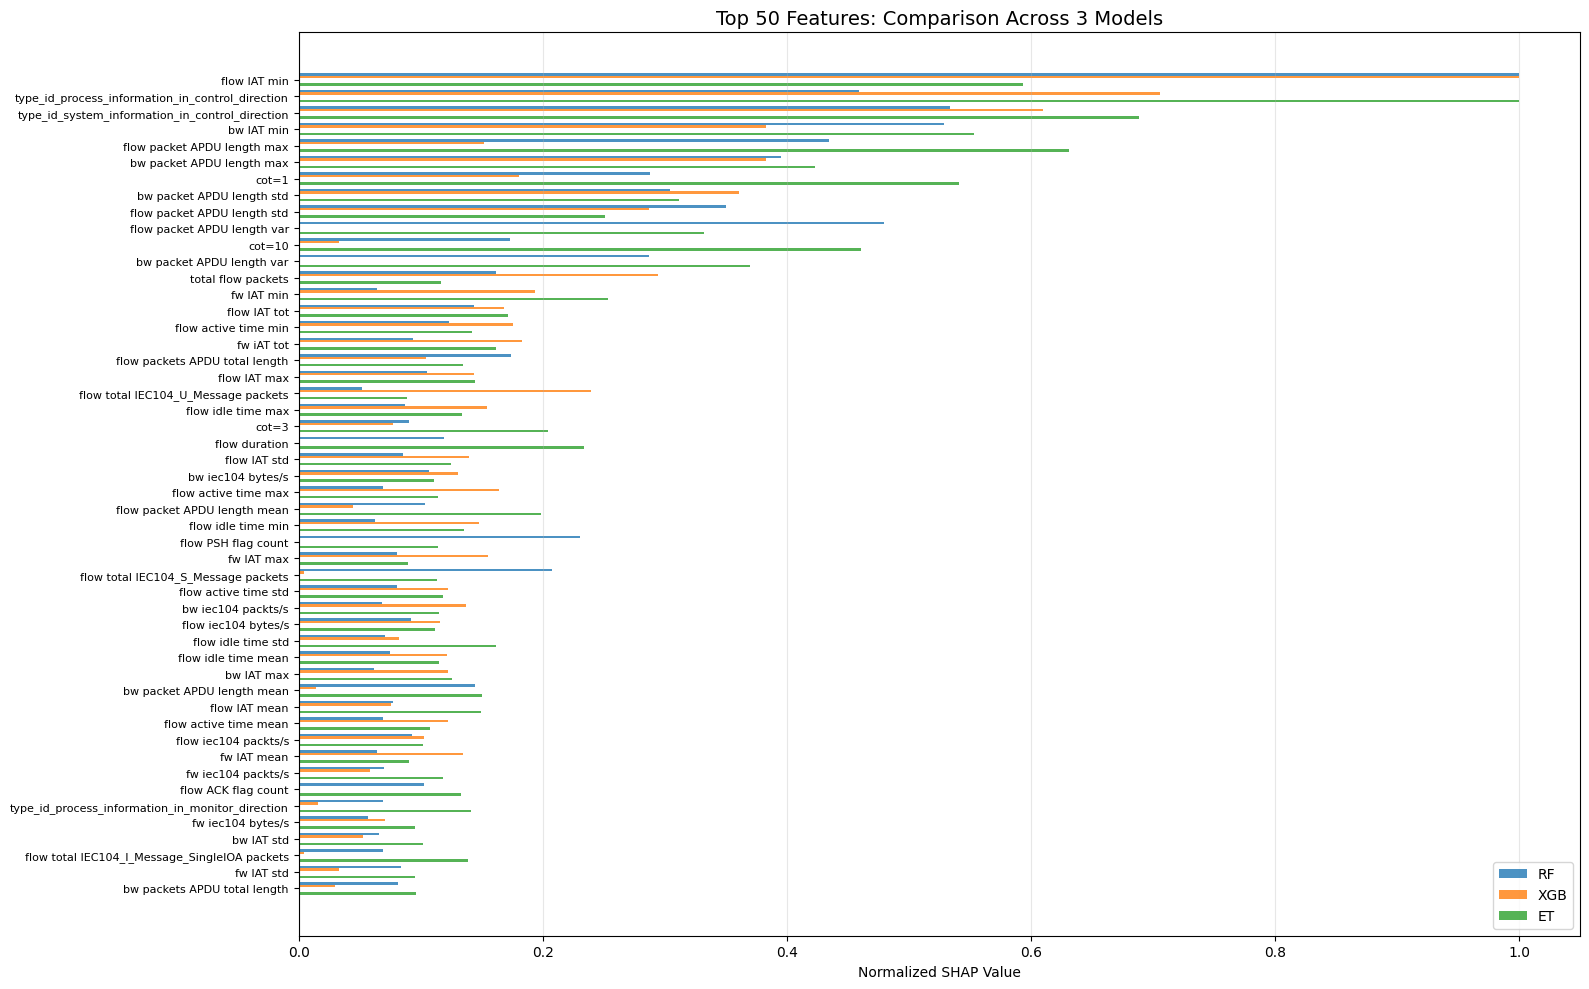

In [7]:
import matplotlib.pyplot as plt
import numpy as np

top_50_plot = final_feature_details.head(50)
x_pos = np.arange(len(top_50_plot))
width = 0.15

plt.figure(figsize=(16, 10))
plt.barh(x_pos - 2*width, top_50_plot['SHAP_RF_Normalized'], width, label='RF', alpha=0.8)
plt.barh(x_pos - width, top_50_plot['SHAP_XGB_Normalized'], width, label='XGB', alpha=0.8)
plt.barh(x_pos + 2*width, top_50_plot['SHAP_ET_Normalized'], width, label='ET', alpha=0.8)

plt.yticks(x_pos, top_50_plot['Feature'], fontsize=8)
plt.xlabel('Normalized SHAP Value')
plt.title('Top 50 Features: Comparison Across 3 Models', fontsize=14)
plt.legend(loc='lower right')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## PLOT 2: Feature Overlap Distribution

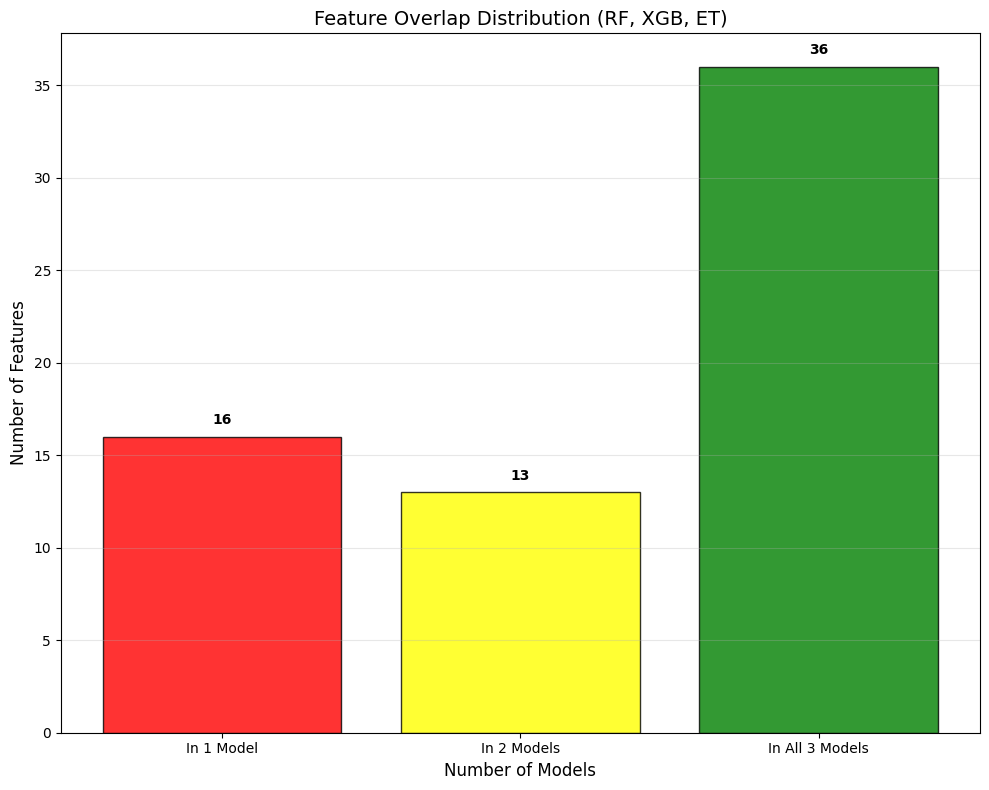

In [8]:
import matplotlib.pyplot as plt

overlap_counts = [sum(1 for c in feature_counts.values() if c == i) for i in range(1, 4)]

plt.figure(figsize=(10, 8))
plt.bar(range(1, 4), overlap_counts,
        color=['red', 'yellow', 'green'],
        edgecolor='black', alpha=0.8)

plt.xlabel('Number of Models', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.title('Feature Overlap Distribution (RF, XGB, ET)', fontsize=14)
plt.xticks(range(1, 4), ['In 1 Model', 'In 2 Models', 'In All 3 Models'])
plt.grid(axis='y', alpha=0.3)

for i, count in enumerate(overlap_counts, 1):
    plt.text(i, count + 0.5, str(count),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## PLOT 3: Combined Score Distribution

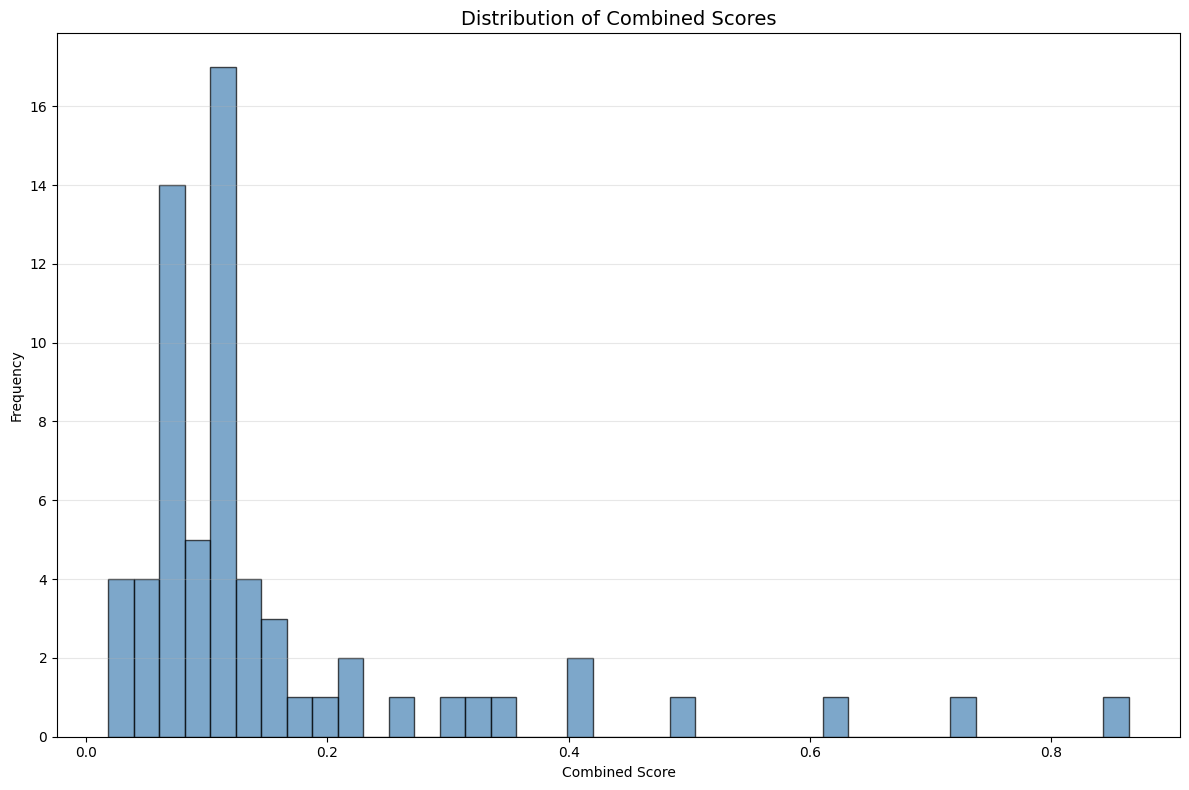

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.hist(final_feature_details['Combined_Score'], bins=40,
         edgecolor='black', alpha=0.7, color='steelblue')

plt.xlabel('Combined Score')
plt.ylabel('Frequency')
plt.title('Distribution of Combined Scores', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## PLOT 4: SHAP Correlation Heatmap

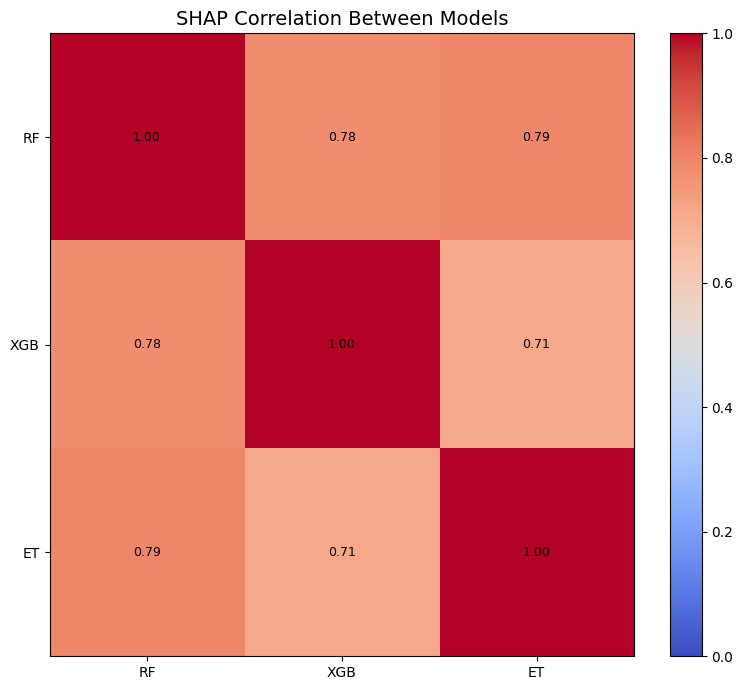

In [10]:
import matplotlib.pyplot as plt

corr_data = final_feature_details[[
    'SHAP_RF_Normalized', 'SHAP_XGB_Normalized', 'SHAP_ET_Normalized']].corr()

plt.figure(figsize=(8, 7))
im = plt.imshow(corr_data, cmap='coolwarm', aspect='auto', vmin=0, vmax=1)
plt.xticks(range(3), ['RF', 'XGB', 'ET'], fontsize=10)
plt.yticks(range(3), ['RF', 'XGB', 'ET'], fontsize=10)
plt.title('SHAP Correlation Between Models', fontsize=14)
plt.colorbar(im)

for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{corr_data.iloc[i, j]:.2f}',
                 ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()


## PLOT 5: Top 15 Features Detailed Comparison

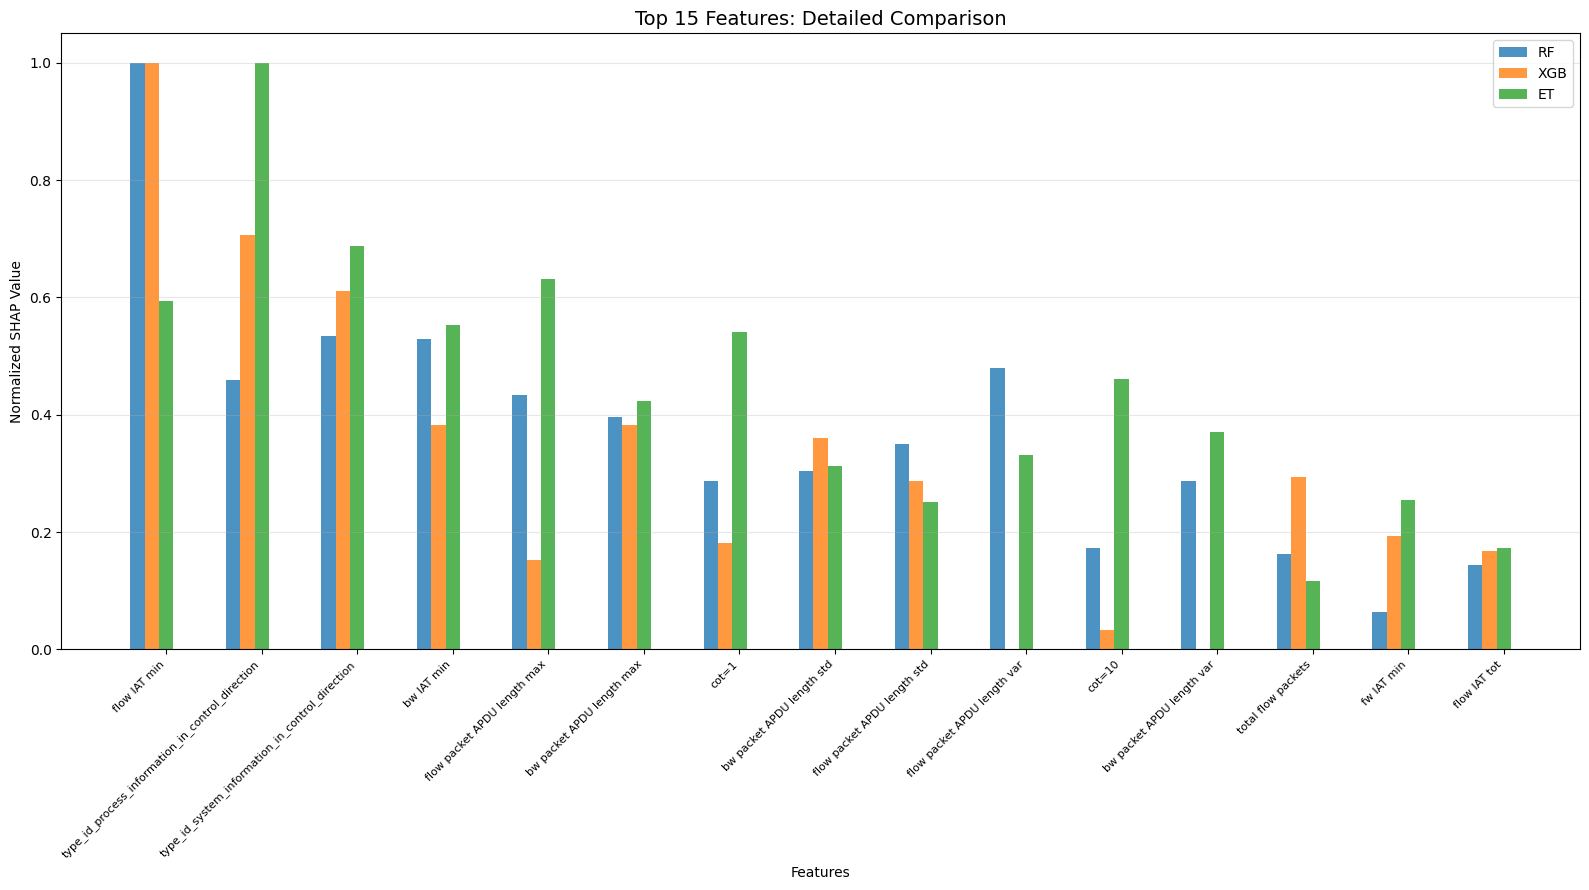

In [11]:
import matplotlib.pyplot as plt
import numpy as np

top_15_plot = final_feature_details.head(15)
models_cols = ['SHAP_RF_Normalized', 'SHAP_XGB_Normalized', 'SHAP_ET_Normalized']
x = np.arange(len(top_15_plot))
width = 0.15

plt.figure(figsize=(16, 9))
for i, (col, label) in enumerate(zip(models_cols, ['RF', 'XGB', 'ET'])):
    offset = width * (i - 2)
    plt.bar(x + offset, top_15_plot[col], width, label=label, alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Normalized SHAP Value')
plt.title('Top 15 Features: Detailed Comparison', fontsize=14)
plt.xticks(x, top_15_plot['Feature'], rotation=45, ha='right', fontsize=8)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# EXPORT

In [12]:
print("\n" + "="*70)
print("EXPORT")
print("="*70)

print("\n Selected features list:")
print("\nfinal_features = [")
for i, feat in enumerate(final_features_sorted):
    if i < len(final_features_sorted) - 1:
        print(f"    '{feat}',")
    else:
        print(f"    '{feat}'")
print("]")

print("\n Variables created:")
print("   - X_train_selected")
print("   - X_test_selected")
print("   - final_features_sorted (list)")
print("   - feature_importance_combined (DataFrame)")

print(f"\n Summary:")
print(f"   Total features: {len(X_train.columns)}")
print(f"   Selected features (union of top 40): {len(final_features_sorted)}")


EXPORT

 Selected features list:

final_features = [
    'flow IAT min',
    'type_id_process_information_in_control_direction',
    'type_id_system_information_in_control_direction',
    'bw IAT min',
    'flow packet APDU length max',
    'bw packet APDU length max',
    'cot=1',
    'bw packet APDU length std',
    'flow packet APDU length std',
    'flow packet APDU length var',
    'cot=10',
    'bw packet APDU length var',
    'total flow packets',
    'fw IAT min',
    'flow IAT tot',
    'flow active time min',
    'fw iAT tot',
    'flow packets APDU total length',
    'flow IAT max',
    'flow total IEC104_U_Message packets',
    'flow idle time max',
    'cot=3',
    'flow duration',
    'flow IAT std',
    'bw iec104 bytes/s',
    'flow active time max',
    'flow packet APDU length mean',
    'flow idle time min',
    'flow PSH flag count',
    'fw IAT max',
    'flow total IEC104_S_Message packets',
    'flow active time std',
    'bw iec104 packts/s',
    'flow iec104 b

In [13]:
print(len(final_features))

65


In [14]:
new_train = X_train_selected.copy()
new_train['Label'] = y_train
new_test = X_test_selected.copy()
new_test['Label'] = y_test

new_train.to_csv(f'./dataset/train_shap_{len(final_features)}.csv',index=False)
new_test.to_csv(f'./dataset/test_shap_{len(final_features)}.csv',index=False)

# Training

In [15]:
import pandas as pd 
import numpy as np
import joblib
import time
import sklearn.metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier

In [16]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

In [17]:
X_train2 = new_train.drop(['Label'], axis=1)
y_train2 = new_train['Label']
X_test2 = new_test.drop(['Label'], axis=1)
y_test2 = new_test['Label']

## ExtraTrees

In [18]:
et_params = {
    "n_estimators": 200,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy"
}

print("ExtraTreesClassifier Starting")
et_model = ExtraTreesClassifier(**et_params)
et_model.fit(X=X_train2, y=y_train2)
et_start_time = time.time()
et_prediction = et_model.predict(X_test2)
et_end_time = time.time()
et_time = et_end_time - et_start_time
print("ExtraTreesClassifier Finished")

et_acc = sklearn.metrics.accuracy_score(y_true=y_test2, y_pred=et_prediction)
et_precision = sklearn.metrics.precision_score(y_true=y_test2, y_pred=et_prediction, average='macro')
et_f1 = sklearn.metrics.f1_score(y_true=y_test2, y_pred=et_prediction, average='macro')
et_recall = sklearn.metrics.recall_score(y_true=y_test2, y_pred=et_prediction, average='macro')
et_cm = sklearn.metrics.confusion_matrix(y_true=y_test2, y_pred=et_prediction)
et_fp = et_cm[0, 1]
print("ExtraTrees report:")
print("ExtraTrees Time:", et_end_time - et_start_time)
print("ExtraTrees Accuracy:", et_acc)
print("ExtraTrees Precision:", et_precision)
print("ExtraTrees F1:", et_f1)
print("ExtraTrees Recall:", et_recall)
print("ExtraTrees CM:\n", et_cm)
et_tpr, et_fpr = calculate_macro_tpr_fpr(et_cm)
print(f'ExtraTrees Macro-average TPR: {et_tpr}')
print(f'ExtraTrees Macro-average FPR: {et_fpr}')

ExtraTreesClassifier Starting
ExtraTreesClassifier Finished
ExtraTrees report:
ExtraTrees Time: 0.15857315063476562
ExtraTrees Accuracy: 0.8520710059171598
ExtraTrees Precision: 0.8496222651432842
ExtraTrees F1: 0.8475621187269949
ExtraTrees Recall: 0.8520710059171598
ExtraTrees CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 169   0   0   0   0   0   0   0   0   0]
 [  0   0   0 169   0   0   0   0   0   0   0   0]
 [  0   0   0   0 169   0   0   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  0   1  30   0   0   0   0  77  36  10  15   0]
 [  0   0   0   0   0   0   0  36 133   0   0   0]
 [  0   0  11   0   0   0   0   6   0 100  52   0]
 [  0   0   0   0   0   0   0   1   0 102  66   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
ExtraTrees Macro-average TPR: 0.8520710059171598
ExtraTrees Macro-average FPR: 0.013448090371167294
